In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
import uuid

np.random.seed(42)

metadata = pd.read_csv('metadata.csv')

n_samples = len(metadata)
n_genes = 1000  # Example: 1000 genes
genes = [f'gene_{i}' for i in range(n_genes)]
tpm_data = pd.DataFrame(
    np.random.lognormal(mean=2, sigma=1, size=(n_samples, n_genes)),
    index=metadata['id'],
    columns=genes
)

data = tpm_data.join(metadata[['id', 'organ', 'age']].set_index('id'))

print(data.head())

                               gene_0     gene_1     gene_2     gene_3  \
id                                                                       
GTEX-11LCK-0126_spleen_1    12.142530   6.434896  14.121360  33.886946   
GTEX-11LCK-0126_spleen_2    29.944793  18.627401   7.843070   3.869260   
GTEX-11P82-1126_prostate_1   3.761515   6.394776   3.345379   5.430539   
GTEX-11P82-1126_prostate_2   1.096576   3.125565   4.886100  48.797918   
GTEX-11P82-1126_prostate_3   3.115864   7.162052   7.523390  11.853585   

                               gene_4     gene_5     gene_6     gene_7  \
id                                                                       
GTEX-11LCK-0126_spleen_1     5.846520   5.846616  35.845313  15.917748   
GTEX-11LCK-0126_spleen_2    14.853319  10.951598  18.086996  13.945708   
GTEX-11P82-1126_prostate_1   1.112250   9.145790   7.397969   3.263863   
GTEX-11P82-1126_prostate_2  12.891306   1.943554  12.013563   1.572546   
GTEX-11P82-1126_prostate_3   1.883519

In [2]:
tpm_log = np.log2(tpm_data + 1)

scaler = StandardScaler()
tpm_normalized = pd.DataFrame(
    scaler.fit_transform(tpm_log),
    index=tpm_log.index,
    columns=tpm_log.columns
)

print("Normalized TPM shape:", tpm_normalized.shape)

Normalized TPM shape: (90, 1000)


In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
import uuid

np.random.seed(42)

metadata = pd.read_csv('metadata.csv')

n_samples = len(metadata)
n_genes = 1000  
genes = [f'gene_{i}' for i in range(n_genes)]
tpm_data = pd.DataFrame(
    np.random.lognormal(mean=2, sigma=1, size=(n_samples, n_genes)),
    index=metadata['id'],
    columns=genes
)

data = tpm_data.join(metadata[['id', 'organ', 'age']].set_index('id'))

print(data.head())

                               gene_0     gene_1     gene_2     gene_3  \
id                                                                       
GTEX-11LCK-0126_spleen_1    12.142530   6.434896  14.121360  33.886946   
GTEX-11LCK-0126_spleen_2    29.944793  18.627401   7.843070   3.869260   
GTEX-11P82-1126_prostate_1   3.761515   6.394776   3.345379   5.430539   
GTEX-11P82-1126_prostate_2   1.096576   3.125565   4.886100  48.797918   
GTEX-11P82-1126_prostate_3   3.115864   7.162052   7.523390  11.853585   

                               gene_4     gene_5     gene_6     gene_7  \
id                                                                       
GTEX-11LCK-0126_spleen_1     5.846520   5.846616  35.845313  15.917748   
GTEX-11LCK-0126_spleen_2    14.853319  10.951598  18.086996  13.945708   
GTEX-11P82-1126_prostate_1   1.112250   9.145790   7.397969   3.263863   
GTEX-11P82-1126_prostate_2  12.891306   1.943554  12.013563   1.572546   
GTEX-11P82-1126_prostate_3   1.883519

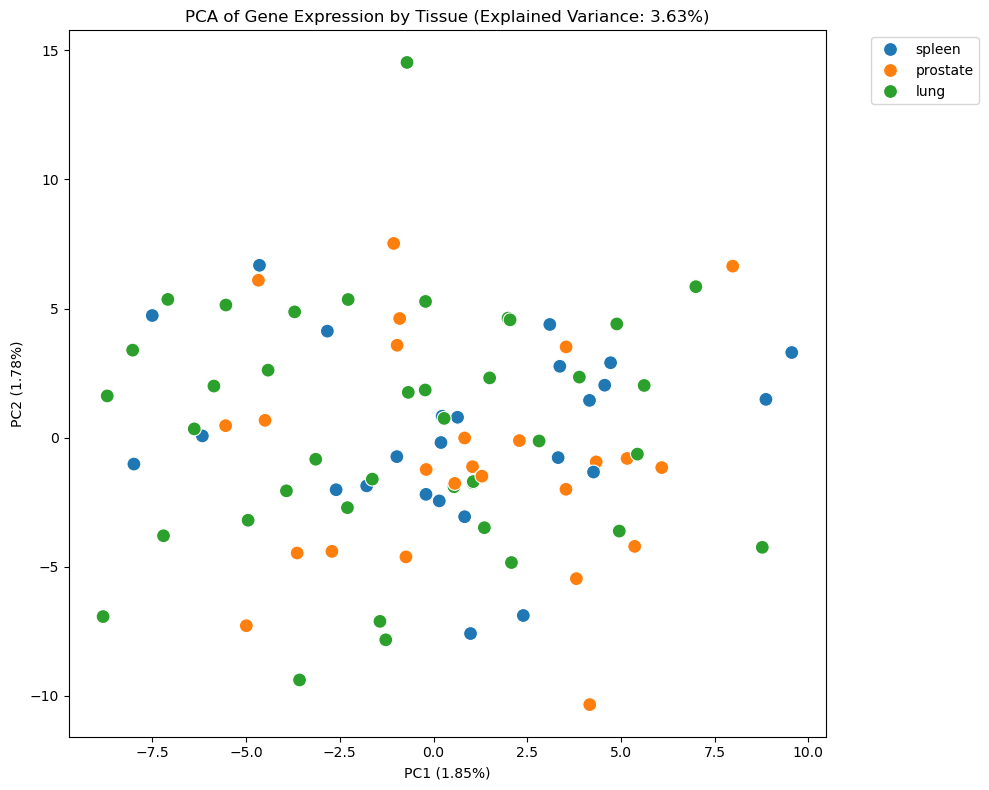

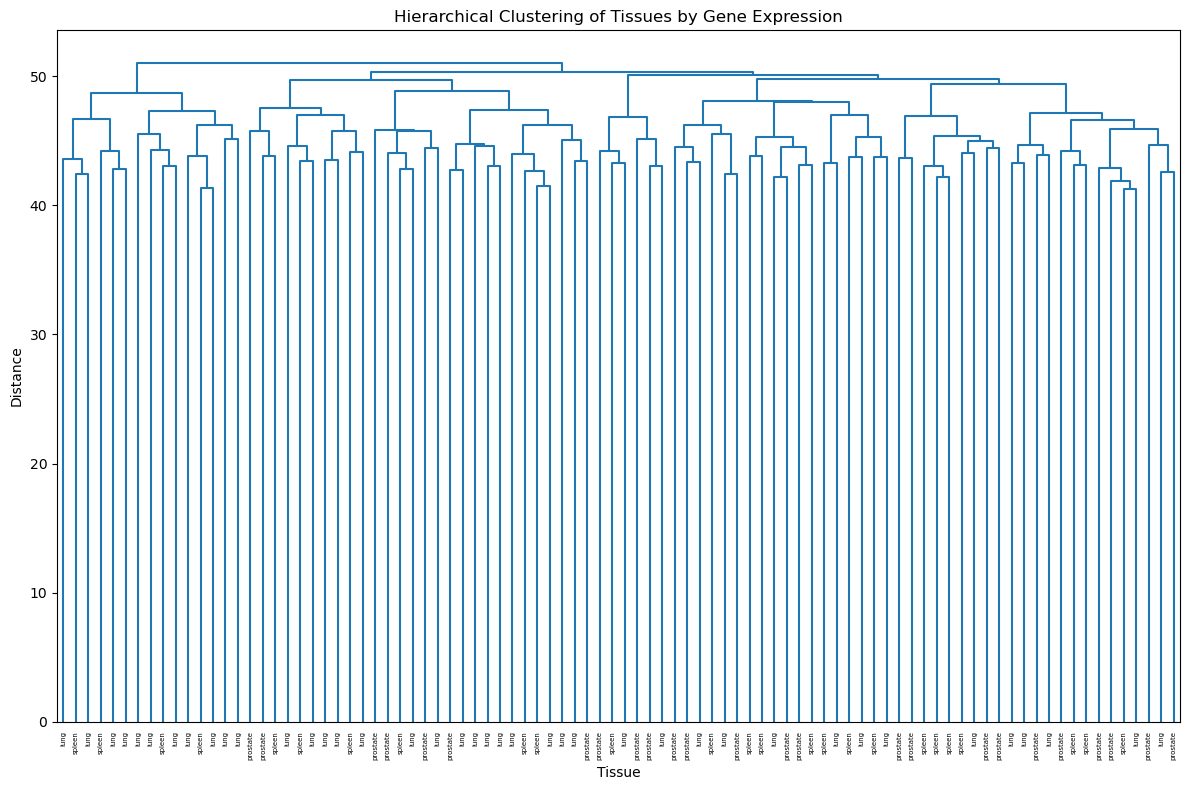

In [4]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(tpm_normalized)
pca_df = pd.DataFrame(pca_result, index=tpm_normalized.index, columns=['PC1', 'PC2'])
pca_df['organ'] = data['organ']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='organ', s=100)
plt.title(f'PCA of Gene Expression by Tissue (Explained Variance: {pca.explained_variance_ratio_.sum():.2%})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig(f'pca_tissue_{uuid.uuid4()}.png')
plt.show()

linkage_matrix = linkage(tpm_normalized, method='ward')
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=data['organ'].values, leaf_rotation=90)
plt.title('Hierarchical Clustering of Tissues by Gene Expression')
plt.xlabel('Tissue')
plt.ylabel('Distance')
plt.tight_layout()

plt.savefig(f'dendrogram_tissue_{uuid.uuid4()}.png')
plt.show()

C:\Users\Legion\AppData\Local\Temp\ipykernel_20576\249871847.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  variability = tpm_normalized.groupby(data['age_bin']).std().mean(axis=1)


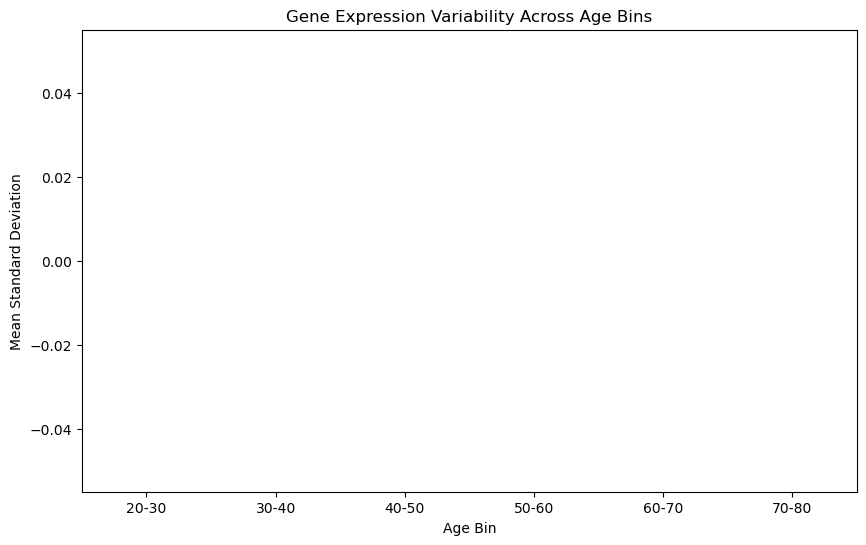

In [5]:
age_bins = pd.cut(data['age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70-80'])
data['age_bin'] = age_bins
variability = tpm_normalized.groupby(data['age_bin']).std().mean(axis=1)
plt.figure(figsize=(10, 6))
sns.barplot(x=variability.index, y=variability.values)
plt.title('Gene Expression Variability Across Age Bins')
plt.xlabel('Age Bin')
plt.ylabel('Mean Standard Deviation')
plt.savefig(f'age_variability_{uuid.uuid4()}.png')
plt.show()

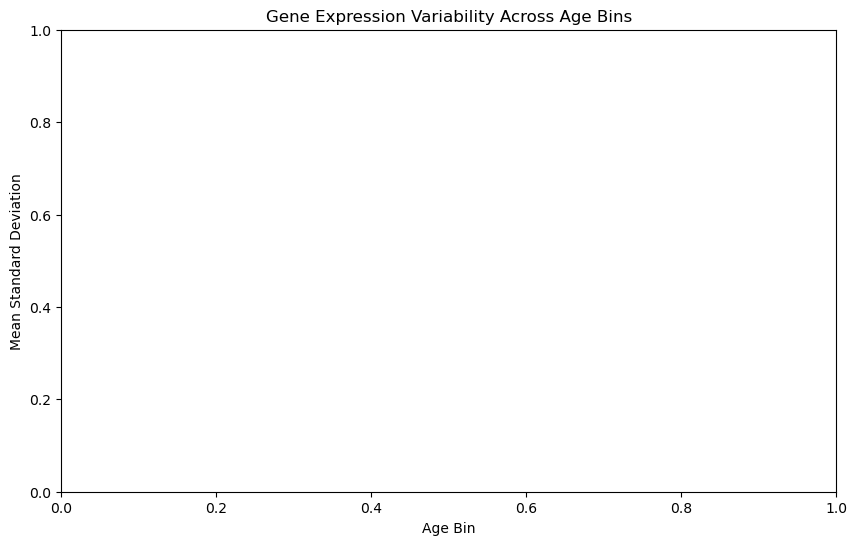

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
import uuid
np.random.seed(42)
metadata = pd.read_csv('metadata.csv')
age_bins = pd.cut(data['age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70-80'])
data['age_bin'] = age_bins
variability = tpm_normalized.groupby(data['age_bin'], observed=True).std().mean(axis=1)
plt.figure(figsize=(10, 6))
sns.barplot(x=variability.index, y=variability.values)
plt.title('Gene Expression Variability Across Age Bins')
plt.xlabel('Age Bin')
plt.ylabel('Mean Standard Deviation')
plt.savefig(f'age_variability_{uuid.uuid4()}.png')
plt.show()

In [ ]:
#Well, I've had several problems with this dataset. First of all it was genetics themed and at that time it was the biggest dataset for me. I used AI to help me code and explain me the functions, but still as you can see I have a certain struggles regarding that 